# **Gradient Descent with Momentum & Nesterov Momentum**

In [1]:
import torch
from matplotlib import pyplot

##**Gradient Descent**

In [2]:
def init_inputs(r_min=-2.0, r_max=2.0):
    inputs = torch.arange(r_min, r_max+0.1, 0.1)
    return inputs

In [3]:
init_inputs(r_min=-2.0, r_max=2.0)

tensor([-2.0000e+00, -1.9000e+00, -1.8000e+00, -1.7000e+00, -1.6000e+00,
        -1.5000e+00, -1.4000e+00, -1.3000e+00, -1.2000e+00, -1.1000e+00,
        -1.0000e+00, -9.0000e-01, -8.0000e-01, -7.0000e-01, -6.0000e-01,
        -5.0000e-01, -4.0000e-01, -3.0000e-01, -2.0000e-01, -1.0000e-01,
        -5.9605e-09,  1.0000e-01,  2.0000e-01,  3.0000e-01,  4.0000e-01,
         5.0000e-01,  6.0000e-01,  7.0000e-01,  8.0000e-01,  9.0000e-01,
         1.0000e+00,  1.1000e+00,  1.2000e+00,  1.3000e+00,  1.4000e+00,
         1.5000e+00,  1.6000e+00,  1.7000e+00,  1.8000e+00,  1.9000e+00,
         2.0000e+00])

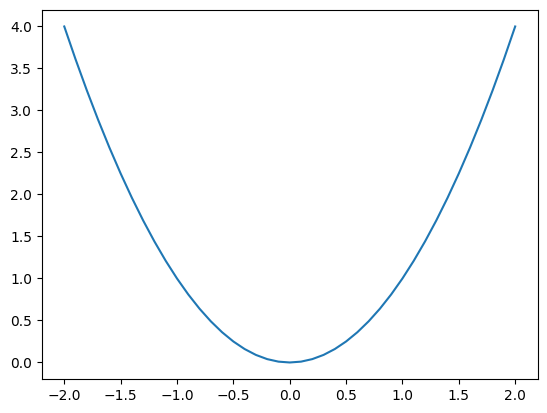

In [4]:
# objective function
def objective(x):
 return x**2.0

inputs = init_inputs()
results = objective(inputs)
pyplot.plot(inputs, results)
pyplot.show()

In [5]:
def objective(x):
    return x**2.0

def derivative(x):
    return 2.0*x

def sgd(input, num_epochs, learning_rate):
    solutions, scores = [], []
    solution = input
    solution_eval = objective(solution)
    solutions.append(solution)
    scores.append(solution_eval)

    for epoch in range(num_epochs):
        # calculate gradient
        gradient = derivative(solution)
        # take a step
        solution = solution - learning_rate * gradient
        # evaluate candidate point
        solution_eval = objective(solution)
        # store solution
        solutions.append(solution)
        scores.append(solution_eval)
        # report progress
        print('Epoch: %0.2d -- f(%0.3f) = %.5f' % (
            epoch, solution, solution_eval))
    return solutions, scores

In [6]:
num_epochs = 20
learning_rate = 0.1
inputs = init_inputs()
input = inputs[0]
solutions, scores = sgd(input, num_epochs, learning_rate)

Epoch: 00 -- f(-1.600) = 2.56000
Epoch: 01 -- f(-1.280) = 1.63840
Epoch: 02 -- f(-1.024) = 1.04858
Epoch: 03 -- f(-0.819) = 0.67109
Epoch: 04 -- f(-0.655) = 0.42950
Epoch: 05 -- f(-0.524) = 0.27488
Epoch: 06 -- f(-0.419) = 0.17592
Epoch: 07 -- f(-0.336) = 0.11259
Epoch: 08 -- f(-0.268) = 0.07206
Epoch: 09 -- f(-0.215) = 0.04612
Epoch: 10 -- f(-0.172) = 0.02951
Epoch: 11 -- f(-0.137) = 0.01889
Epoch: 12 -- f(-0.110) = 0.01209
Epoch: 13 -- f(-0.088) = 0.00774
Epoch: 14 -- f(-0.070) = 0.00495
Epoch: 15 -- f(-0.056) = 0.00317
Epoch: 16 -- f(-0.045) = 0.00203
Epoch: 17 -- f(-0.036) = 0.00130
Epoch: 18 -- f(-0.029) = 0.00083
Epoch: 19 -- f(-0.023) = 0.00053


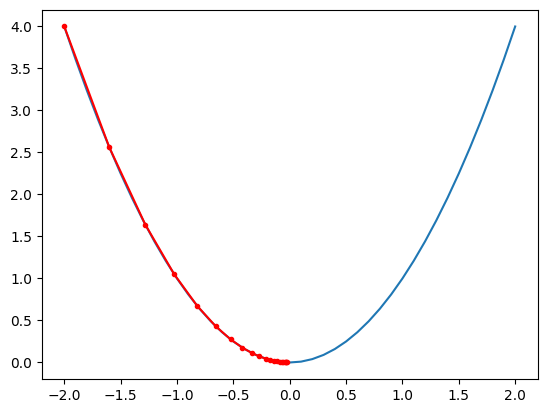

In [7]:
results = objective(inputs)
pyplot.plot(inputs, results)
pyplot.plot(solutions, scores, '.-', color='red')
pyplot.show()

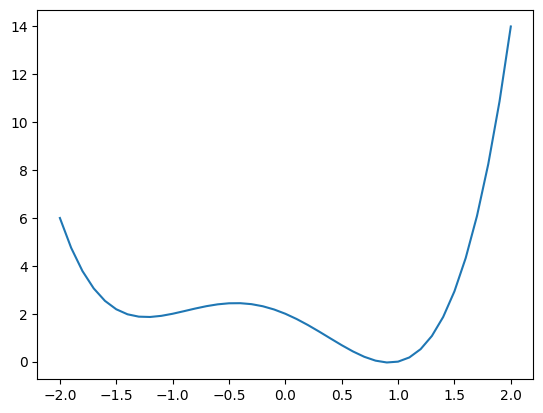

In [41]:
def objective(x):
 return x**4+x**3-2*x**2-2*x+2

inputs = init_inputs()
results = objective(inputs)
pyplot.plot(inputs, results)
pyplot.show()

In [42]:
# objective function
def objective(x):
 return x**4+x**3-2*x**2-2*x+2

# derivative of objective function
def derivative(x):
    return 4*x**3 + 3*x**2 - 4*x - 2

num_epochs = 20
learning_rate = 0.1
inputs = init_inputs()
input = inputs[0]
solutions, scores = sgd(input, num_epochs, learning_rate)

Epoch: 00 -- f(-0.600) = 2.39360
Epoch: 01 -- f(-0.662) = 2.34977
Epoch: 02 -- f(-0.742) = 2.27775
Epoch: 03 -- f(-0.840) = 2.17372
Epoch: 04 -- f(-0.951) = 2.05123
Epoch: 05 -- f(-1.059) = 1.94550
Epoch: 06 -- f(-1.144) = 1.88629
Epoch: 07 -- f(-1.195) = 1.86667
Epoch: 08 -- f(-1.219) = 1.86278
Epoch: 09 -- f(-1.228) = 1.86225
Epoch: 10 -- f(-1.231) = 1.86219
Epoch: 11 -- f(-1.232) = 1.86218
Epoch: 12 -- f(-1.232) = 1.86218
Epoch: 13 -- f(-1.232) = 1.86218
Epoch: 14 -- f(-1.232) = 1.86218
Epoch: 15 -- f(-1.232) = 1.86218
Epoch: 16 -- f(-1.232) = 1.86218
Epoch: 17 -- f(-1.232) = 1.86218
Epoch: 18 -- f(-1.232) = 1.86218
Epoch: 19 -- f(-1.232) = 1.86218


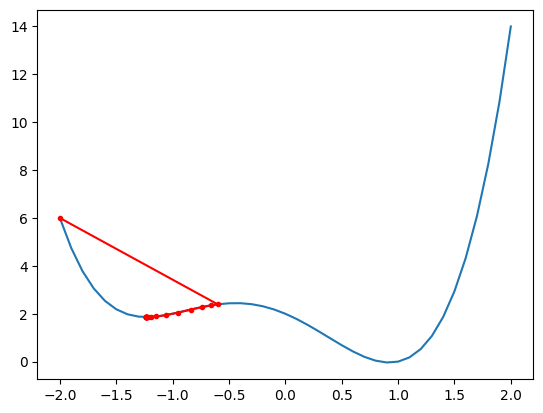

In [43]:
results = objective(inputs)
pyplot.plot(inputs, results)
pyplot.plot(solutions, scores, '.-', color='red')
pyplot.show()

##**Gradient Descent with Momentum**

In [44]:
# gradient descent algorithm
def gradient_descent_with_momentum(input, num_epochs, learning_rate, momentum):
    solutions, scores = [], []
    solution = input
    # keep track of the change
    change = 0.0
    solution_eval = objective(solution)
    solutions.append(solution)
    scores.append(solution_eval)

    for epoch in range(num_epochs):
        # calculate gradient
        gradient = derivative(solution)
        # calculate update
        new_change = learning_rate * gradient + momentum * change
        # take a step
        solution = solution - new_change
        # save the change
        change = new_change
        # evaluate candidate point
        solution_eval = objective(solution)
        # store solution
        solutions.append(solution)
        scores.append(solution_eval)
        # report progress
        print('Epoch: %0.2d -- f(%0.3f) = %.5f' % (
            epoch, solution, solution_eval))
    return solutions, scores

In [45]:
num_epochs = 20
learning_rate = 0.1
inputs = init_inputs()
input = inputs[0]
# define momentum
momentum = 0.8
solutions, scores = gradient_descent_with_momentum(
    input, num_epochs, learning_rate, momentum
)

Epoch: 00 -- f(-0.600) = 2.39360
Epoch: 01 -- f(0.458) = 0.80342
Epoch: 02 -- f(1.587) = 4.12767
Epoch: 03 -- f(0.970) = -0.02355
Epoch: 04 -- f(0.417) = 0.91993
Epoch: 05 -- f(0.260) = 1.36561
Epoch: 06 -- f(0.412) = 0.93599
Epoch: 07 -- f(0.819) = 0.02011
Epoch: 08 -- f(1.251) = 0.77579
Epoch: 09 -- f(1.045) = 0.05894
Epoch: 10 -- f(0.714) = 0.17647
Epoch: 11 -- f(0.636) = 0.33875
Epoch: 12 -- f(0.804) = 0.03617
Epoch: 13 -- f(1.058) = 0.08299
Epoch: 14 -- f(1.075) = 0.11555
Epoch: 15 -- f(0.875) = -0.02500
Epoch: 16 -- f(0.767) = 0.08598
Epoch: 17 -- f(0.831) = 0.00746
Epoch: 18 -- f(0.978) = -0.01892
Epoch: 19 -- f(1.025) = 0.02997


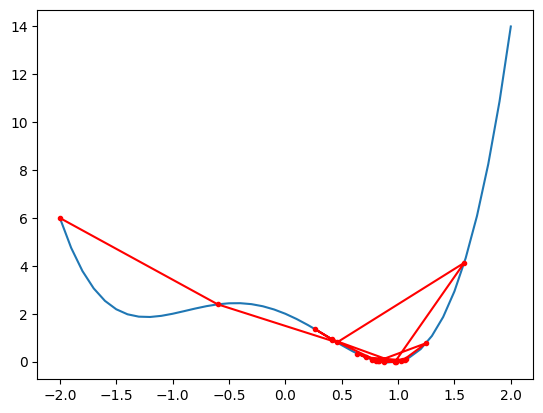

In [46]:
results = objective(inputs)
pyplot.plot(inputs, results)
pyplot.plot(solutions, scores, '.-', color='red')
pyplot.show()

In [64]:
num_epochs = 20
learning_rate = 0.1
inputs = init_inputs()
input = inputs[0]
# define momentum
momentum = 0.9
solutions, scores = gradient_descent_with_momentum(
    input, num_epochs, learning_rate, momentum
)

Epoch: 00 -- f(-0.600) = 2.39360
Epoch: 01 -- f(0.598) = 0.42953
Epoch: 02 -- f(1.923) = 11.54945
Epoch: 03 -- f(0.130) = 1.70891
Epoch: 04 -- f(-1.238) = 1.86230
Epoch: 05 -- f(-2.465) = 16.72587
Epoch: 06 -- f(-0.186) = 2.29804
Epoch: 07 -- f(1.982) = 13.40041
Epoch: 08 -- f(0.633) = 0.34654
Epoch: 09 -- f(-0.349) = 2.42692
Epoch: 10 -- f(-1.193) = 1.86716
Epoch: 11 -- f(-1.977) = 5.69188
Epoch: 12 -- f(-1.354) = 1.92053
Epoch: 13 -- f(-0.692) = 2.32423
Epoch: 14 -- f(-0.184) = 2.29484
Epoch: 15 -- f(0.393) = 0.99066
Epoch: 16 -- f(1.198) = 0.51256
Epoch: 17 -- f(1.484) = 2.74218
Epoch: 18 -- f(0.567) = 0.50747
Epoch: 19 -- f(0.000) = 1.99974


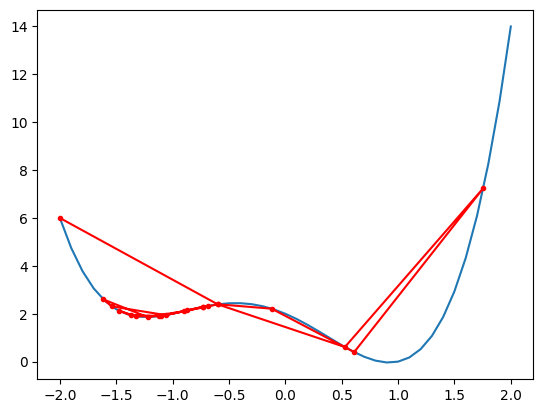

In [60]:
results = objective(inputs)
pyplot.plot(inputs, results)
pyplot.plot(solutions, scores, '.-', color='red')
pyplot.show()

##**Nesterov Momentum**

In [61]:
# gradient descent algorithm
def nesterov_momentum(input, num_epochs, learning_rate, momentum):
    solutions, scores = [], []
    solution = input
    # keep track of the change
    change = 0.0
    solution_eval = objective(solution)
    solutions.append(solution)
    scores.append(solution_eval)

    for epoch in range(num_epochs):
        # calculate the projected solution
        projected = solution + momentum * change
        # calculate gradient
        gradient = derivative(projected)
        # calculate update
        new_change = momentum * change - learning_rate * gradient
        # take a step
        solution = solution + new_change
        # save the change
        change = new_change
        # evaluate candidate point
        solution_eval = objective(solution)
        # store solution
        solutions.append(solution)
        scores.append(solution_eval)
        # report progress
        print('Epoch: %0.2d -- f(%0.3f) = %.5f' % (
            epoch, solution, solution_eval))
    return solutions, scores

In [63]:
num_epochs = 20
learning_rate = 0.1
inputs = init_inputs()
input = inputs[0]
# define momentum
momentum = 0.8
solutions, scores = nesterov_momentum(
    input, num_epochs, learning_rate, momentum
)

Epoch: 00 -- f(-0.600) = 2.39360
Epoch: 01 -- f(0.791) = 0.05350
Epoch: 02 -- f(-0.979) = 2.02096
Epoch: 03 -- f(0.623) = 0.36945
Epoch: 04 -- f(-0.989) = 2.01098
Epoch: 05 -- f(0.186) = 1.56569
Epoch: 06 -- f(0.824) = 0.01403
Epoch: 07 -- f(0.583) = 0.46906
Epoch: 08 -- f(0.676) = 0.25254
Epoch: 09 -- f(0.913) = -0.03720
Epoch: 10 -- f(0.843) = -0.00331
Epoch: 11 -- f(0.921) = -0.03774
Epoch: 12 -- f(0.906) = -0.03626
Epoch: 13 -- f(0.926) = -0.03766
Epoch: 14 -- f(0.918) = -0.03766
Epoch: 15 -- f(0.924) = -0.03773
Epoch: 16 -- f(0.921) = -0.03774
Epoch: 17 -- f(0.923) = -0.03775
Epoch: 18 -- f(0.922) = -0.03775
Epoch: 19 -- f(0.922) = -0.03775


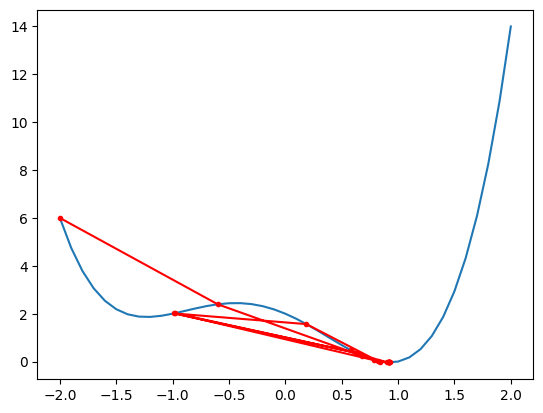

In [56]:
results = objective(inputs)
pyplot.plot(inputs, results)
pyplot.plot(solutions, scores, '.-', color='red')
pyplot.show()

##**SGD with Momentum - Pytorch**

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [ ]:
data = load_iris()

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    data.data,
    data.target,
    test_size=0.4
)

In [ ]:
X_valid, X_test, Y_valid, Y_test = train_test_split(
    X_test,
    Y_test,
    test_size=0.5
)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
scaler.fit(X_train)

StandardScaler()

In [ ]:
X_train = scaler.transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train)
X_valid = torch.tensor(X_valid, dtype=torch.float32)
Y_valid = torch.tensor(Y_valid)
X_test = torch.tensor(X_test, dtype=torch.float32)
Y_test = torch.tensor(Y_test)

In [ ]:
model_classifier = nn.Sequential(
    nn.Linear(4, 8),
    nn.Linear(8, 8),
    nn.ReLU(),
    nn.Linear(8, 3)
)

In [ ]:
loss_fn = nn.CrossEntropyLoss()

In [ ]:
learning_rate = 0.01

optimizer = optim.SGD(
    model_classifier.parameters(),
    lr=learning_rate,
    momentum=0.8
)

In [ ]:
def evaluate(model_classifier, X_valid, Y_valid):
    with torch.no_grad():
        Y_pred = model_classifier(X_valid)

    Y_pred = torch.argmax(Y_pred, dim=1)
    return sum(Y_pred == Y_valid)/len(Y_valid)

In [ ]:
num_epochs = 50
losses = []
for epoch in range(num_epochs):
    epoch_loss = []
    for x_train, y_train in zip(X_train, Y_train):
        y_pred = model_classifier(x_train)
        loss = loss_fn(y_pred, y_train)
        epoch_loss.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    avg_loss = sum(epoch_loss)/len(epoch_loss)
    acc = evaluate(model_classifier, X_valid, Y_valid)
    print(f"{avg_loss} -- {acc}")

0.7878451061331564 -- 0.800000011920929
0.39891867534671394 -- 0.8666666746139526
0.24051756431840154 -- 0.8999999761581421
0.14866542639113808 -- 0.9333333373069763
0.120677385777041 -- 0.9333333373069763
0.11210784485988876 -- 0.9333333373069763
0.10454605993383868 -- 0.9666666388511658
0.1018077214681398 -- 0.9666666388511658
0.10374881529792725 -- 0.9666666388511658
0.10299417164854074 -- 0.9666666388511658
0.10073353498743624 -- 0.9666666388511658
0.09226181499460483 -- 0.9666666388511658
0.08773626018460164 -- 0.9666666388511658
0.08378491928020695 -- 0.9666666388511658
0.08004064121699281 -- 0.9666666388511658
0.0757756723782677 -- 0.9666666388511658
0.07332683244158918 -- 0.9666666388511658
0.07203438523558564 -- 0.9666666388511658
0.07083510896739098 -- 0.9666666388511658
0.06962563716001821 -- 0.9666666388511658
0.06844108859281353 -- 0.9666666388511658
0.06727045905887255 -- 0.9666666388511658
0.06614908452653102 -- 0.9666666388511658
0.06510445954372951 -- 0.966666638851165

In [ ]:
with torch.no_grad():
    Y_pred = model_classifier(X_test)

In [ ]:
Y_pred = torch.argmax(Y_pred, dim=1)

In [ ]:
sum(Y_pred == Y_test)/len(Y_test)

tensor(0.9667)